In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Setting plot style globally
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
 
print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


STEP2 - LOAD DATASET

In [13]:
# Make sure loan_data.csv is inside the data/ folder
df = pd.read_csv("data/loan_data.csv")

In [14]:
# Drop the unnamed index column Kaggle adds
df.drop(columns=["Unnamed: 0"], inplace=True, errors="ignore")

In [15]:
print(f"✅ Dataset loaded! Shape: {df.shape}")
# Shape tells you: (number of rows, number of columns)

✅ Dataset loaded! Shape: (150000, 11)


STEP 3 - UNDERSTAND THE COLUMNS

In [16]:
print("\n📋 Column Names:")
print(df.columns.tolist())


📋 Column Names:
['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


In [17]:
print("\n📊 First 5 Rows:")
print(df.head())


📊 First 5 Rows:
   SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
0                 1                              0.766127   45   
1                 0                              0.957151   40   
2                 0                              0.658180   38   
3                 0                              0.233810   30   
4                 0                              0.907239   49   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
0                                     2   0.802982         9120.0   
1                                     0   0.121876         2600.0   
2                                     1   0.085113         3042.0   
3                                     0   0.036050         3300.0   
4                                     1   0.024926        63588.0   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
0                               13                        0   
1                                4           

In [18]:
print("\n🔢 Data Types:")
print(df.dtypes)


🔢 Data Types:
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object


STEP 4 - BASIC STATISTICS

In [19]:
print("\n📈 Summary Statistics:")
print(df.describe())
# This shows min, max, mean, std for each column
# Look for: very large max values (outliers), 0 minimum values (missing?)


📈 Summary Statistics:
       SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines            age  \
count     150000.000000                         150000.000000  150000.000000   
mean           0.066840                              6.048438      52.295207   
std            0.249746                            249.755371      14.771866   
min            0.000000                              0.000000       0.000000   
25%            0.000000                              0.029867      41.000000   
50%            0.000000                              0.154181      52.000000   
75%            0.000000                              0.559046      63.000000   
max            1.000000                          50708.000000     109.000000   

       NumberOfTime30-59DaysPastDueNotWorse      DebtRatio  MonthlyIncome  \
count                         150000.000000  150000.000000   1.202690e+05   
mean                               0.421033     353.005076   6.670221e+03   
std                      

STEP 5 - CHECK MISSING VALUES

In [22]:
print("\n❓ Missing Values:")
missing = df.isnull().sum()
print(missing)
total_rows = len(df)

print("MonthlyIncome missing:", round(29731/total_rows * 100, 2), "%")
print("NumberOfDependents missing:", round(3924/total_rows * 100, 2), "%")
# WHY THIS MATTERS: ML models cannot handle NaN values.
# We need to decide: fill them (imputation) or drop them.


❓ Missing Values:
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64
MonthlyIncome missing: 19.82 %
NumberOfDependents missing: 2.62 %


GRAPH - shows class imbalance

Out of 150,000 people:

Around 140,000 never defaulted → tall blue bar
Around 10,000 actually defaulted → tiny red bar

That's roughly 93% vs 7%.

Why This Is a Problem
Imagine you're teaching a student with 100 exam questions — but 93 are from Chapter 1 and only 7 from Chapter 2.
The student will get very good at Chapter 1 and completely ignore Chapter 2.
Your ML model does the same thing. If we train it as-is, it will just predict "no default" for everyone and still be 93% accurate — but it's completely useless because it never catches actual defaulters.
That's called class imbalance. And it's exactly why we use SMOTE in Week 3 — to balance the classes artificially.

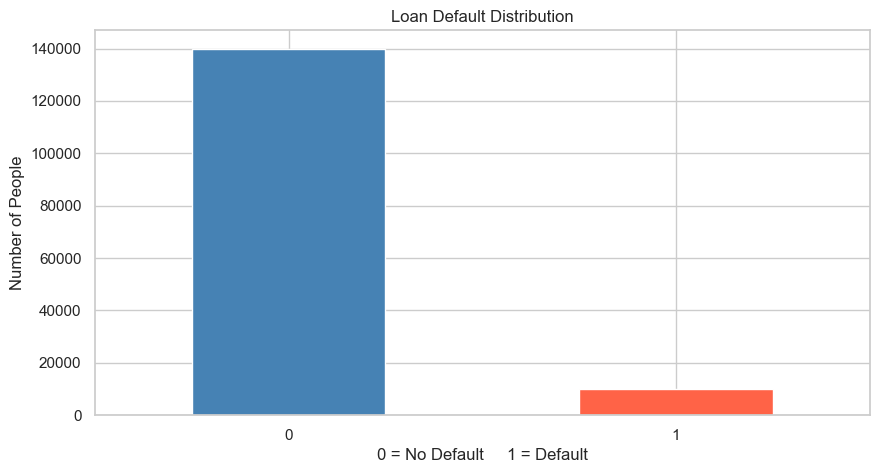

In [23]:
df["SeriousDlqin2yrs"].value_counts().plot(kind="bar", color=["steelblue", "tomato"])

plt.title("Loan Default Distribution")
plt.xlabel("0 = No Default     1 = Default")
plt.ylabel("Number of People")
plt.xticks(rotation=0)
plt.show()

In [24]:
print(df["SeriousDlqin2yrs"].value_counts())   #First print → raw count of 0s and 1s
print()
print(df["SeriousDlqin2yrs"].value_counts(normalize=True) * 100)        #same thing but as percentage

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

SeriousDlqin2yrs
0    93.316
1     6.684
Name: proportion, dtype: float64


"The dataset had significant class imbalance — 93.3% of borrowers did not default while only 6.7% did. If I trained a model directly on this, it would simply predict no default for everyone and still show 93% accuracy, which is misleading. So I used SMOTE in the preprocessing stage to synthetically oversample the minority class and balance the dataset before training."

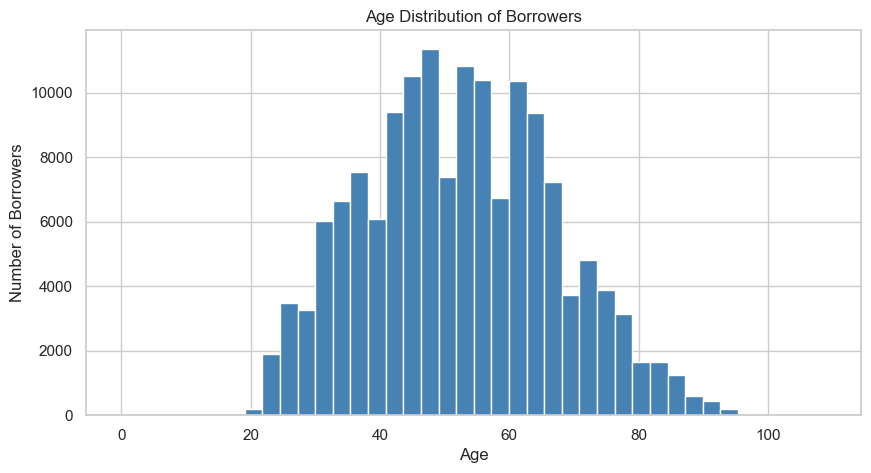

In [26]:
plt.hist(df["age"], bins=40, color="steelblue", edgecolor="white")
plt.title("Age Distribution of Borrowers")
plt.xlabel("Age")
plt.ylabel("Number of Borrowers")
plt.show()

What bins=40 means:

It divides the age range into 40 equal sections
Each bar in the histogram represents one section
More bars = more detail in the graph

what age group has the most borrowers?
40–60 is the dominant age group. That makes real-world sense too.
Why? People in their 40s–50s are most likely to take loans — they have stable jobs, buy houses, cars, fund children's education. Younger people (20s) earn less so banks give fewer loans. Older people (60+) are near retirement so they borrow less.

Cell 10 — Check for Outliers in Age

In [27]:
print("Minimum age:", df["age"].min())
print("Maximum age:", df["age"].max())

Minimum age: 0
Maximum age: 109


Why we're checking this: Real people can't be 0 years old or 120 years old. Sometimes datasets have garbage entries like age = 0. We need to catch those before training our model.

In [29]:
print(df[df["age"] == 0])  #Check How Many Rows Have Age = 0, This filters your dataframe and shows only rows where age is 0.
print(len(df[df["age"] == 0]))

       SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
65695                 0                                   1.0    0   

       NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
65695                                     1   0.436927         6000.0   

       NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
65695                                6                        0   

       NumberRealEstateLoansOrLines  NumberOfTime60-89DaysPastDueNotWorse  \
65695                             2                                     0   

       NumberOfDependents  
65695                 2.0  
1


Only 1 row has age = 0. That's easy to handle — we'll simply remove that one bad row.

What You Just Did
You found a real data quality issue by yourself. This is exactly what Data Scientists do every day — hunt for bad data before it corrupts the model.
In your interview you can say:

"During EDA I found one record with age = 0 which is clearly invalid. I removed that row during data cleaning."

In [31]:
print(len(df[df["age"] > 100]))  #Cell 12 — Check Age = 109

13


13 people with age above 100 in the dataset
We'll remove them. Here's why — a 101 or 109 year old taking a loan is almost certainly a data entry error. And 13 rows out of 150,000 is 0.008% — so removing them won't affect our model at all.

Your EDA Problems List So Far
You've now personally found 4 real data issues:
#ProblemHow You Found It1MonthlyIncome — 19.82% missingisnull().sum()2NumberOfDependents — 2.62% missingisnull().sum()3Age = 0 → 1 bad rowdf[df["age"]==0]4Age > 100 → 13 bad rowsdf[df["age"]>100]

In [32]:
#This will show us if there are any unrealistic income values hiding in the data.
print("Minimum Income:", df["MonthlyIncome"].min())
print("Maximum Income:", df["MonthlyIncome"].max())
print("Median Income:", df["MonthlyIncome"].median())
print("Mean Income:", df["MonthlyIncome"].mean())

Minimum Income: 0.0
Maximum Income: 3008750.0
Median Income: 5400.0
Mean Income: 6670.221237392844


The Key Insight Here
Mean ($6,670) is higher than Median ($5,400).
This proves what we said earlier — a few extremely high earners are pulling the mean upward. The median is unaffected by them.
This is exactly why we'll use median to fill missing income values in Week 2 — not mean.
In your interview say:

"MonthlyIncome had a maximum of $3 million which is clearly an outlier. The mean was $6,670 but the median was $5,400 — this gap confirmed the data was right-skewed. So I used median imputation for missing income values."